# **Tarea 3 | Notebook de regresión**
### Introducción a la Ciencia de Datos 
*Alumno: Norman O. Guzmán Chaboya*

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('bmh')
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import recall_score, accuracy_score, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ran = 42

## 1. Dataset

Los datos corresponden a Wine Quality del *UCI Machine Learning Repository* (licencia CC BY 4.0), y reúnen mediciones fisicoquímicas de variantes del vino portugués "Vinho Verde" (Cortez et al., 2009). Cargamos el archivo de la clasificación de vino (`winequality-red.csv`), que contiene 1,599 vinos descritos por 11 atributos numéricos y su calidad.

In [2]:
data = pd.read_csv("./winequality-red.csv")
data.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### 1.1. Atributos

Los vinos son descritos por 11 variables númericas, que se enlistan a continuación:
- `fixed acidity`: Cantidad de ácido tartárico ($g$/$dm$)
- `volatile acidity`: Cantidad de ácido acético ($g$/$dm^3$)
- `citric acid`: Cantidad de ácido cítrico ($g$/$dm^3$)
- `residual sugar`: Cantidad de azúcar residual ($g$/$dm^3$)
- `chlorides`: Cantidad de cloruro de sodio presente ($g$/$dm^3$)
- `free sulfur dioxide`: Dióxido de azufre libre ($mg$/$dm^3$)
- `total sulfur dioxide`: Dióxido de azufre total ($mg$/$dm^3$)
- `density`: Densidad del vino ($g$/$cm^3$)
- `pH`: Nivel de acidez (escala pH)
- `sulphates`: Sulfato de potasio presente ($g$/$dm^3$)
- `alcohol`: Contenido de alcohol (% del vol.)


In [3]:
def rango(s):
    return f"{s.min().round(2)}-{s.max().round(2)}"


data[:-1].dtypes.to_frame()

var_info = data.dtypes.to_frame(name='datatype')
var_info['range'] = [rango(data[c]) for c in data[:-1].columns]
var_info

,datatype,range
fixed acidity,float64,4.6-15.9
volatile acidity,float64,0.12-1.58
citric acid,float64,0.0-1.0
residual sugar,float64,0.9-15.5
chlorides,float64,0.01-0.61
free sulfur dioxide,float64,1.0-72.0
total sulfur dioxide,float64,6.0-289.0
density,float64,0.99-1.0
pH,float64,2.74-4.01
sulphates,float64,0.33-2.0


### 1.2. Variable Objetivo

La variable objetivo es `quality`, una calificación entera. Se revisa cuántos vinos hay en cada valor y cuál es el rango observado:

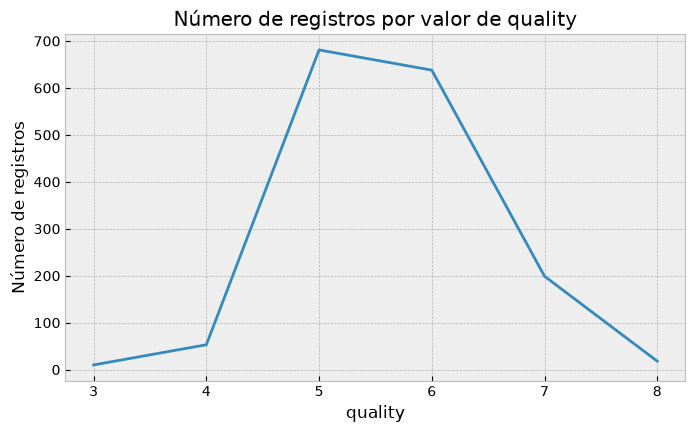

Rango var. objetivo: 3-8


In [4]:
obj = 'quality'
conteo = data[obj].value_counts().sort_index()

with plt.style.context('bmh'):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(conteo.index, conteo.values, linewidth=2)
    ax.set_title(f'Número de registros por valor de {obj}')
    ax.set_xlabel(obj)
    ax.set_ylabel('Número de registros')
    plt.show()

max_obj = np.max(data['quality'])
min_obj = np.min(data['quality'])

print(f'Rango var. objetivo: {min_obj}-{max_obj}')

**Lectura:** De forma muy burda, la variable objetivo aparenta tener una distribución normal. `quality` tiene un solo pico y se concentra en los valores intermedios: (las calificaciones 5 y 6). No existen vinos con calificación menor a 3 ni mayor a 8.

## 2. Análisis Exploratorio

### 2.1. Distribución

Graficamos el histograma de cada atributo para identificar su forma, su escala y la presencia de valores extremos:

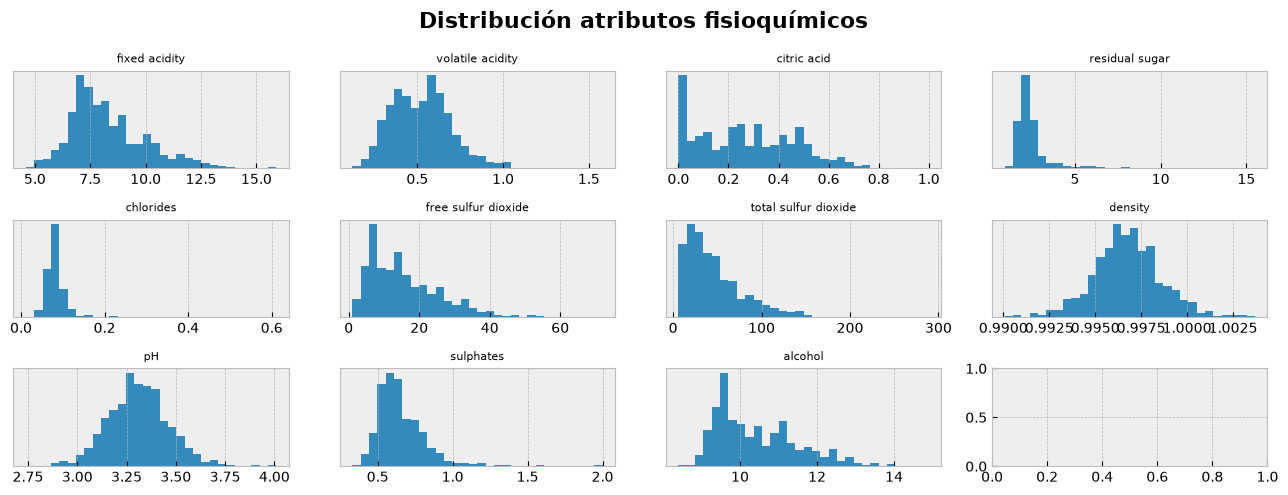

In [5]:
cols_x = data.columns[:-1]

fig, axes = plt.subplots(3, 4, figsize=(13, 5))

# Graficamos el histograma de distribución para cada atributo numérico
with plt.style.context('bmh'):
    for ax, col in zip(axes.ravel(), cols_x):
        ax.hist(data[col], bins=min(data[col].nunique(), 30))
        ax.set_title(col, fontsize=8)
        ax.set_yticks([])
    
    fig.suptitle("Distribución atributos fisioquímicos",
                 fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

**Lectura:** Los atributos presentan formas muy distintas. `density` y `pH` son aproximadamente simétricos y de forma acampanada. En cambio, `chlorides` y `residual sugar` se concentran en valores bajos y muestran colas largas hacia la derecha.

In [6]:
X = data[data.columns[:-1]]     
y = data['quality']

### 2.2. Correlaciones

Calculamos la correlación de Pearson entre cada atributo y `quality`:

In [7]:
X.corrwith(y).sort_values(ascending=False).round(2).to_frame(name='Pearson Coef.')

,Pearson Coef.
alcohol,0.48
sulphates,0.25
citric acid,0.23
fixed acidity,0.12
residual sugar,0.01
free sulfur dioxide,-0.05
pH,-0.06
chlorides,-0.13
density,-0.17
total sulfur dioxide,-0.19


El alcohol es el atributo más asociado con la calidad (0.48), seguido de los sulfatos (0.25) y el ácido cítrico (0.23). En sentido contrario destaca la acidez volátil (−0.39) y, en menor medida, el dióxido de azufre total (−0.19) y la densidad (−0.17).

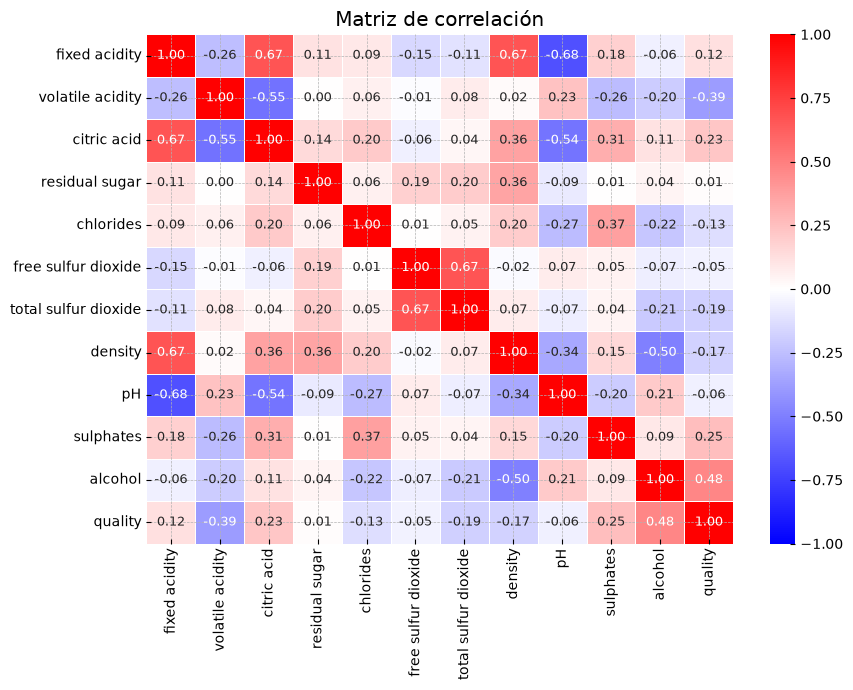

In [8]:
correlaciones = data[data.columns].corr()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(correlaciones, cmap="bwr", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 9},
            linewidths=0.6, linecolor="white", ax=ax)

ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

**Lectura:** El mapa de calor reproduce en su última fila las correlaciones con `quality` y, además, muestra relaciones entre los propios atributos. Las más fuertes son las de `fixed acidity` con `pH` (−0.68). `Alcohol` claramente es la variable que contribuye mayoritariamente al incremento de la var. objetivo, al tiempo que se correlaciona significativa e inversamente a `density`.

### 2.3. Recta de mínimos cuadrados

Con el atributo de mayor correlación, `alcohol`, se ajusta por mínimos cuadrados una recta que describe la calidad. El ajuste se realiza con la totalidad de los vinos y con fines descriptivos, sin separar un conjunto de prueba. La recta se grafica sobre los datos:

In [9]:
y_ = data["quality"].to_numpy()
x = X["alcohol"].to_numpy()
modelo_simple = LinearRegression().fit(X[["alcohol"]], y_)

theta0 = modelo_simple.intercept_
theta1 = modelo_simple.coef_[0]

In [28]:
theta1

np.float64(0.36084176533077456)

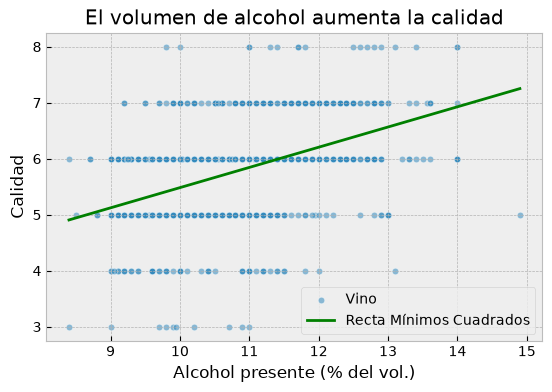

In [10]:
with plt.style.context('bmh'):
    fig, ax = plt.subplots(figsize=(6.4, 4))
    
    ax.scatter(x, y_, s=22, alpha=0.55, edgecolor="white", linewidth=0.5, label="Vino")
    malla = np.linspace(x.min(), x.max(), 100)
    ax.plot(malla, theta0 + theta1 * malla, linewidth=2, color="green", label="Recta Mínimos Cuadrados")
    
    ax.set_xlabel("Alcohol presente (% del vol.)")
    ax.set_ylabel("Calidad")
    ax.set_title("El volumen de alcohol aumenta la calidad")
    ax.legend()
    plt.show()

**Lectura:** De acuerdo al regresor, cada punto porcentual adicional de alcohol se asocia con un aumento aproximado de 0.36 puntos de calidad. `quality` solo toma valores enteros, los vinos se alinean en franjas horizontales, y en cada nivel de alcohol aparecen vinos de calidades muy distintas, esto resulta digno de atención, ya que la regresión lineal se ajusta a un valor continuo que se predice al momento.

## 3. Clasificación

Ahora, el objetivo es decidir si el vino es "bueno" o no. Se define $buenos = 1$ cuando `quality` $≥ 7$ y $buenos = 0$ en los demás casos. Se mantiene la regresión lineal, pero entrenada con etiquetas 0 y 1. Se utiliza 0.5 como umbral para asignar la clase.

In [11]:
buenos = (y >= 7).astype(int)          # 1: vino bueno; 0: vino no tan bueno
print(f"De buena calidad: {buenos.sum()} de {len(buenos)} vinos ({buenos.mean():.0%})")

De buena calidad: 217 de 1599 vinos (14%)


Solo el 14% de los vinos alcanzan una calificación de 7 o más, por lo que las clases están desbalanceadas.

Se separa el 80% de los vinos para entrenamiento y el 20% para prueba (320 vinos), se ajusta la regresión con los 11 atributos y se convierte su salida continua, y se asigna un clase de acuerdo al umbral:

In [12]:
X_entrena_c, X_prueba_c, buenos_entrena, buenos_prueba = train_test_split(
    X, buenos, test_size=0.2, random_state=ran)

recta = LinearRegression().fit(X_entrena_c, buenos_entrena)
y_gorro = recta.predict(X_prueba_c)        # salida continua
clase = (y_gorro >= 0.5).astype(int)   # clase según umbral = 0.5

In [13]:
recta.intercept_
recta.coef_[0]

np.float64(0.0332271246481736)



Se utilizan el siguiente par de métricas para evaluar los resultados de la regresión:


- Exactitud (*accuracy*): proporción de instancias clasificadas correctamente, sin distinguir entre clases.

$$\text{Accuracy} = \frac{VP + VN}{VP + VN + FP + FN}$$

- Sensibilidad (*Recall*): del total de verdaderos positivos, proporción que el modelo logra identificar, contando aquellos cosos en que descarta la clase erróneamente:

$$\text{Recall} = \frac{VP}{VP + FN}$$


Recuerdo (Recall): 0.1064
Exactitud (Accuracy): 0.8625


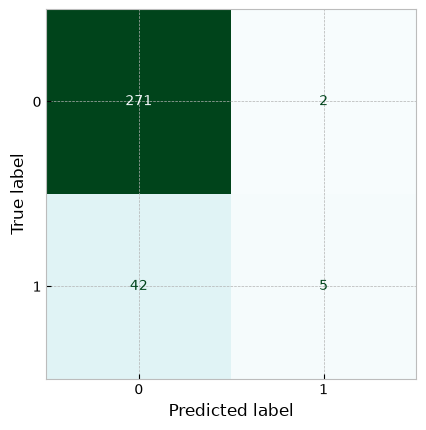

In [20]:
matriz_conf = confusion_matrix(buenos_prueba, clase)
recall = recall_score(buenos_prueba, clase) 
exactitud = accuracy_score(buenos_prueba, clase)

print(f"Recuerdo (Recall): {recall:.4f}")
print(f"Exactitud (Accuracy): {exactitud:.4f}")

ConfusionMatrixDisplay(matriz_conf, display_labels=[0, 1]).plot(cmap='BuGn', colorbar=False)
with plt.style.context('bmh'):
    plt.show()

De los 320 vinos de prueba, 47 son buenos. El modelo clasifica correctamente 271 de los 273 vinos no buenos (2 falsos positivos), pero solo 5 de los 47 buenos (42 falsos negativos); por ello, el recall es de apenas 0.11, mientras que la exactitud es de 0.86. La exactitud alta se explica casi por completo por la clase mayoritaria

In [15]:
def metricas(y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    return {"RMSE": np.sqrt(mse),
            "R²": r2_score(y_real, y_pred)}

pred_base = np.full(len(buenos_prueba), buenos_entrena.mean())   # siempre predice el promedio de entrenamiento

pd.DataFrame({
    "promedio (línea base)": metricas(buenos_prueba, pred_base),
    "regresión lineal": metricas(buenos_prueba, y_gorro),
}).T.round(3)

,RMSE,R²
promedio (línea base),0.354,-0.002
regresión lineal,0.305,0.258


Frente a la línea base (predecir siempre el promedio de entrenamiento), la regresión reduce el RMSE de 0.354 a 0.305 (aproximadamente 14%) y alcanza un R² de 0.258.

In [16]:

siempre_no = np.zeros(len(buenos_prueba), dtype=int)
fuera = ((y_gorro < 0) | (y_gorro > 1)).sum()
detectados = ((clase == 1) & (buenos_prueba == 1)).sum()

print(f"Aciertos de la recta:            {accuracy_score(buenos_prueba, clase):.2%}")
print(f"Aciertos diciendo siempre «no»:  {accuracy_score(buenos_prueba, siempre_no):.2%}")
print(f"ŷ fuera de [0, 1]:               {fuera} de {len(y_gorro)}")
print(f"Progresiones altas detectadas:   {detectados} de {buenos_prueba.sum()}")

Aciertos de la recta:            86.25%
Aciertos diciendo siempre «no»:  85.31%
ŷ fuera de [0, 1]:               82 de 320
Progresiones altas detectadas:   5 de 47


La regresión acierta en el 86% de los vinos y la regla de responder siempre "no" en el 85%. Asimismo, 82 de las 320 predicciones (~25%) quedan fuera del intervalo [0, 1], por lo que no pueden leerse como probabilidades, y solo se detectan 5 de los 47 vinos buenos.

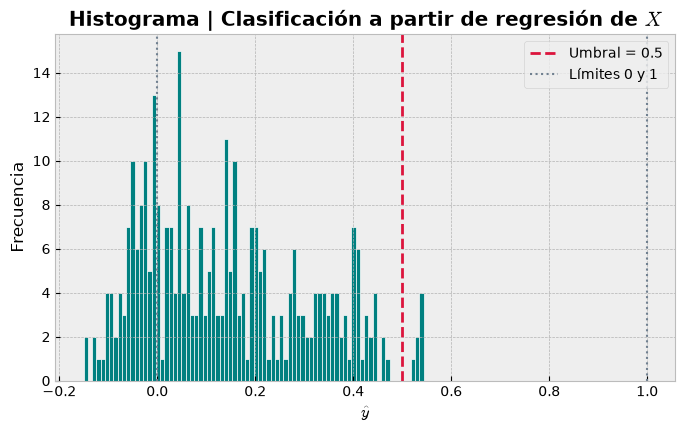

In [26]:
with plt.style.context('bmh'):
    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.hist(y_gorro, bins=80, color='teal', edgecolor='white')
    ax.axvline(0.5, color='crimson', linestyle='--', linewidth=2, label='Umbral = 0.5')
    ax.axvline(0, color='slategrey', linestyle=':', linewidth=1.5, label='Límites 0 y 1')
    ax.axvline(1, color='slategrey', linestyle=':', linewidth=1.5)

    ax.set_title('Histograma | Clasificación a partir de regresión de $X$', fontweight='bold')
    ax.set_xlabel(r'$\hat{y}$')
    ax.set_ylabel('Frecuencia')
    ax.legend(frameon=True)
    plt.show()

**Lectura:** El corte se ubica en la cola derecha de la distribución, de modo que casi todos los vinos, incluidos la mayoría de los buenos, se clasifican como "no bueno" Dicho umbral de 0.5 se favorece la exactitud global y no la detección de la clase de interés.

## 4. Conclusiones

Aunque la regresión lineal sigue siendo útil para ordenar por la jerarquía de calidad a los vinos, una proporción considerable de sus predicciones (82 de 320) quedó por debajo de 0 y ninguna superó 0.54, por lo que sus valores no pueden interpretarse como la probabilidad de que un vino sea bueno.
Este ejempo deja patente que la regresión lineal, con su ajuste continuo, es pésimo para clasificar clases que normalmente toman valores discretos.
Lo mejor en todo caso sería utilizar regresión logística, como la regresión logística, la cual da como resultado probabilidades acotadas entre 0 y 1.

## Referencias

 - Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). *Modeling wine preferences by data mining from physicochemical properties*. Decision Support Systems, 47(4), 547-553. https://doi.org/10.1016/j.dss.2009.05.016